In [3]:
import numpy as np

patient_id = "Amifer"
numpy_dir = "/home/ayeluru/mnt/fourier/repository/vascular-superenhancement-4d-flow/all_patients/corrected_velocities"
numpy_dir = "/home/ayeluru/Desktop/vascular-superenhancement_to-move"
numpy_path = f"{numpy_dir}/{patient_id}.npy"

velocities = np.load(numpy_path)

print(velocities.shape)



(20, 3, 152, 192, 256)


In [6]:
import os
for patient in sorted(os.listdir(numpy_dir)):
    if patient.endswith(".npy"):
        numpy_path = f"{numpy_dir}/{patient}"
        velocities = np.load(numpy_path)
        print(velocities.shape, patient)


(20, 3, 152, 192, 256) Amifer.npy
(20, 3, 136, 256, 178) Amupam.npy
(20, 3, 170, 152, 256) Apuefquor.npy
(20, 3, 144, 178, 256) Aruborn.npy
(20, 3, 140, 192, 256) Asonlig.npy
(20, 3, 122, 178, 256) Badiswu.npy
(20, 3, 140, 178, 256) Balboloop.npy
(20, 3, 148, 204, 256) Befeto.npy
(20, 3, 136, 256, 192) Bephedou.npy
(20, 3, 140, 178, 256) Bibathot.npy
(20, 3, 130, 256, 192) Bigeral.npy
(20, 3, 120, 204, 256) Biswifo.npy
(20, 3, 136, 256, 192) Bitistep.npy
(20, 3, 152, 166, 256) Bogeebo.npy
(20, 3, 140, 204, 256) Bomatog.npy
(20, 3, 120, 192, 256) Boochuto.npy
(20, 3, 140, 178, 256) Boudubat.npy
(20, 3, 120, 178, 256) Boumorim.npy
(20, 3, 140, 192, 256) Bovutou.npy
(20, 3, 162, 204, 256) Bukrukesh.npy
(20, 3, 140, 192, 256) Burapo.npy
(20, 3, 134, 216, 256) Butiswu.npy
(20, 3, 130, 192, 256) Cadedag.npy
(20, 3, 120, 192, 256) Cadotueg.npy
(20, 3, 132, 166, 256) Cefaru.npy
(20, 3, 140, 192, 256) Cemuquey.npy
(20, 3, 140, 166, 256) Ceriba.npy
(20, 3, 152, 178, 256) Ceyebum.npy
(20, 3, 170,

In [2]:
# Add project root to path and import required modules
import sys
sys.path.insert(0, "/home/ayeluru/vascular-superenhancement-4d-flow/src")

from pathlib import Path
import nibabel as nib
from vascular_superenhancement.utils.path_config import load_path_config
from vascular_superenhancement.data_management.patients import Patient

# Load path configuration
path_config = load_path_config("all_patients")
print(f"Repository root: {path_config.repository_root}")
print(f"Working dir: {path_config.working_dir}")


Found project root at: /mnt/yeluru/vascular-superenhancement-4d-flow
Repository root: /home/ayeluru/mnt/fourier/repository/vascular-superenhancement-4d-flow/all_patients
Working dir: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients


In [3]:
def process_corrected_velocities(
    patient: Patient,
    corrected_velocities_dir: Path,
    overwrite: bool = False,
) -> dict[str, Path]:
    """
    Process phase-error-corrected velocity fields and save as NIfTI.
    
    The corrected velocities from the numpy files are smaller than the original
    DICOM velocities because they don't include the partial phase FOV padding.
    This function:
    1. Loads the original velocity NIfTI to get the target shape and affine
    2. Loads the corrected numpy array
    3. Adds symmetric padding to match the original dimensions
    4. Saves each velocity component (vx, vy, vz) as NIfTI
    
    Args:
        patient: Patient object with access to existing NIfTI files
        corrected_velocities_dir: Directory containing {patient_id}.npy files
        overwrite: Whether to overwrite existing corrected velocity files
        
    Returns:
        Dictionary mapping component names to output paths
    """
    # Define paths
    corrected_numpy_path = corrected_velocities_dir / f"{patient.identifier}.npy"
    
    if not corrected_numpy_path.exists():
        raise FileNotFoundError(f"Corrected velocities not found: {corrected_numpy_path}")
    
    # Output paths for corrected velocity NIfTIs
    output_paths = {
        'vx_corr': patient.nifti_dir / f"4d_flow_vx_corr_{patient.identifier}.nii.gz",
        'vy_corr': patient.nifti_dir / f"4d_flow_vy_corr_{patient.identifier}.nii.gz",
        'vz_corr': patient.nifti_dir / f"4d_flow_vz_corr_{patient.identifier}.nii.gz",
    }
    
    # Check if all outputs exist and we shouldn't overwrite
    if all(p.exists() for p in output_paths.values()) and not overwrite:
        print(f"[{patient.identifier}] Corrected velocities already exist, skipping")
        return output_paths
    
    # Load reference velocity NIfTI to get target shape and affine
    # Using vx as reference (all velocity components have the same shape/affine)
    ref_nifti_path = patient.nifti_dir / f"4d_flow_vx_{patient.identifier}.nii.gz"
    if not ref_nifti_path.exists():
        raise FileNotFoundError(
            f"Reference velocity NIfTI not found: {ref_nifti_path}. "
            "Run get_4d_flow() first to create velocity NIfTIs from DICOM."
        )
    
    ref_nifti = nib.load(ref_nifti_path)
    ref_affine = ref_nifti.affine
    ref_shape = ref_nifti.shape  # (X, Y, Z, T) in NIfTI
    print(f"[{patient.identifier}] Reference NIfTI shape: {ref_shape}")
    
    # Load corrected velocities
    # Shape: (timepoints, velocity_channel, slices, rows, columns)
    # Channels: 0=Vx, 1=Vy, 2=Vz
    corr_vel = np.load(corrected_numpy_path).astype(np.float32)
    print(f"[{patient.identifier}] Corrected numpy shape: {corr_vel.shape}")
    
    T_corr, C_corr, Z_corr, R_corr, C_cols_corr = corr_vel.shape
    assert C_corr == 3, f"Expected 3 velocity channels, got {C_corr}"
    
    # Reference shape is (X, Y, Z, T) where:
    # X = columns, Y = rows, Z = slices, T = timepoints
    X_ref, Y_ref, Z_ref, T_ref = ref_shape
    
    # Corrected shape interpretation:
    # rows -> Y, columns -> X, slices -> Z, timepoints -> T
    X_corr = C_cols_corr  # columns
    Y_corr = R_corr       # rows  
    
    print(f"[{patient.identifier}] Corrected: X={X_corr}, Y={Y_corr}, Z={Z_corr}, T={T_corr}")
    print(f"[{patient.identifier}] Reference: X={X_ref}, Y={Y_ref}, Z={Z_ref}, T={T_ref}")
    
    # Calculate symmetric padding needed for each dimension
    # The corrected data is missing the partial phase FOV padding
    pad_X = (X_ref - X_corr)
    pad_Y = (Y_ref - Y_corr)
    pad_Z = (Z_ref - Z_corr)
    
    # Verify padding is non-negative and even (symmetric)
    assert pad_X >= 0, f"Corrected X dim ({X_corr}) larger than reference ({X_ref})"
    assert pad_Y >= 0, f"Corrected Y dim ({Y_corr}) larger than reference ({Y_ref})"
    assert pad_Z >= 0, f"Corrected Z dim ({Z_corr}) larger than reference ({Z_ref})"
    
    # Symmetric padding: half on each side
    pad_X_before = pad_X // 2
    pad_X_after = pad_X - pad_X_before
    pad_Y_before = pad_Y // 2
    pad_Y_after = pad_Y - pad_Y_before
    pad_Z_before = pad_Z // 2
    pad_Z_after = pad_Z - pad_Z_before
    
    print(f"[{patient.identifier}] Padding: X=({pad_X_before},{pad_X_after}), Y=({pad_Y_before},{pad_Y_after}), Z=({pad_Z_before},{pad_Z_after})")
    
    # Verify timepoints match
    if T_corr != T_ref:
        print(f"[{patient.identifier}] WARNING: Timepoint mismatch! Corrected={T_corr}, Reference={T_ref}")
    
    # Process each velocity component
    component_map = {0: 'vx_corr', 1: 'vy_corr', 2: 'vz_corr'}
    
    for channel_idx, comp_name in component_map.items():
        # Extract this velocity component: shape (T, Z, R, C) -> (T, Z, Y, X)
        vel_component = corr_vel[:, channel_idx, :, :, :]  # (T, Z, Y, X)
        
        # Transpose to match NIfTI convention: (T, Z, Y, X) -> (X, Y, Z, T)
        vel_component = np.transpose(vel_component, (3, 2, 1, 0))  # (X, Y, Z, T)
        
        # Apply symmetric padding
        # np.pad format: ((before_0, after_0), (before_1, after_1), ...)
        vel_padded = np.pad(
            vel_component,
            (
                (pad_X_before, pad_X_after),  # X dimension
                (pad_Y_before, pad_Y_after),  # Y dimension
                (pad_Z_before, pad_Z_after),  # Z dimension
                (0, 0),                       # T dimension (no padding)
            ),
            mode='constant',
            constant_values=0,
        )
        
        print(f"[{patient.identifier}] {comp_name}: padded shape {vel_padded.shape}")
        
        # Verify final shape matches reference
        assert vel_padded.shape[:3] == ref_shape[:3], \
            f"Shape mismatch after padding: {vel_padded.shape} vs {ref_shape}"
        
        # Create NIfTI image with the reference affine
        nii = nib.Nifti1Image(vel_padded, ref_affine)
        nii.set_qform(ref_affine, code=1)
        nii.set_sform(ref_affine, code=1)
        
        # Set header info
        hdr = nii.header
        hdr['dim'][0] = 4
        hdr['dim'][4] = vel_padded.shape[3]
        hdr['pixdim'][4] = 1.0  # Time spacing
        hdr['xyzt_units'] = 2 | 8  # mm + seconds
        
        # Save
        output_path = output_paths[comp_name]
        nib.save(nii, output_path)
        print(f"[{patient.identifier}] Saved {comp_name} to {output_path}")
    
    return output_paths

print("Function defined: process_corrected_velocities")


Function defined: process_corrected_velocities


## characterize all the diffs

In [1]:
def get_venc(patient_id: str) -> float:
    
    import pandas as pd
    import pydicom
    """
    Get the VENC (velocity encoding) value for a patient from their 4D flow DICOM catalog.
    
    Args:
        patient_id: The patient identifier string
        
    Returns:
        The VENC value from DICOM tag (0x0019, 0x10CC)
    """
    patient_4d_flow_dicom_catalog = f'/home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/{patient_id}/dicom_catalog_4d-flow_{patient_id}.csv'
    
    flow_catalog = pd.read_csv(patient_4d_flow_dicom_catalog)
    first_filepath = flow_catalog.iloc[0]['filepath']
    
    dcm = pydicom.dcmread(first_filepath)
    venc = dcm[0x0019, 0x10CC].value
    
    return venc


Repository root: /home/ayeluru/mnt/fourier/repository/vascular-superenhancement-4d-flow/all_patients
Working dir: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients
Corrected velocities directory: /home/ayeluru/mnt/fourier/repository/vascular-superenhancement-4d-flow/all_patients/corrected_velocities


  0%|          | 0/283 [00:00<?, ?it/s]


Patient: Amifer
NIfTI dir: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Amifer/nifti
VENC: 1500

Difference statistics vx:
  Max abs diff: 1.0000
  Mean abs diff: 0.0126
  Non-zero voxels in corrected: 45754

Difference statistics vy:
  Max abs diff: 1.0000
  Mean abs diff: 0.0086
  Non-zero voxels in corrected: 45628


  0%|          | 1/283 [00:23<1:49:46, 23.36s/it]


Difference statistics vz:
  Max abs diff: 1.0000
  Mean abs diff: 0.0092
  Non-zero voxels in corrected: 46039

Patient: Amupam
NIfTI dir: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Amupam/nifti
VENC: 3499

Difference statistics vx:
  Max abs diff: 1.0000
  Mean abs diff: 0.0289
  Non-zero voxels in corrected: 45100

Difference statistics vy:
  Max abs diff: 1.0000
  Mean abs diff: 0.0263
  Non-zero voxels in corrected: 44947


  1%|          | 2/283 [00:45<1:44:44, 22.37s/it]


Difference statistics vz:
  Max abs diff: 0.9634
  Mean abs diff: 0.0332
  Non-zero voxels in corrected: 45121

Patient: Apuefquor
NIfTI dir: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Apuefquor/nifti
VENC: 2500

Difference statistics vx:
  Max abs diff: 0.0440
  Mean abs diff: 0.0075
  Non-zero voxels in corrected: 37524


  1%|          | 2/283 [00:59<2:19:27, 29.78s/it]


KeyboardInterrupt: 

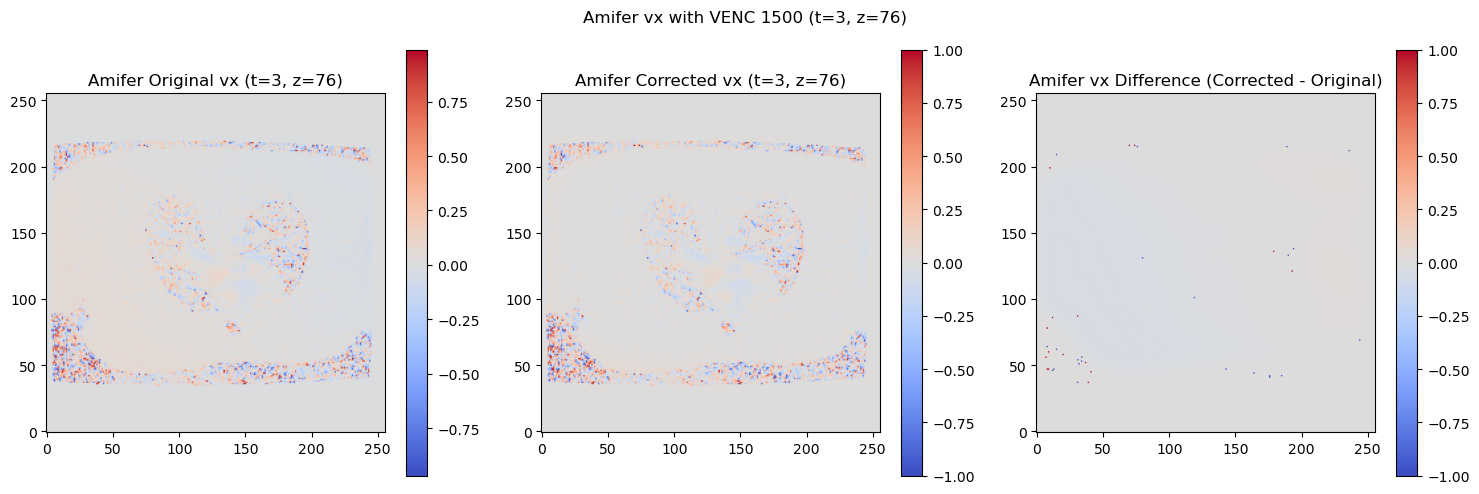

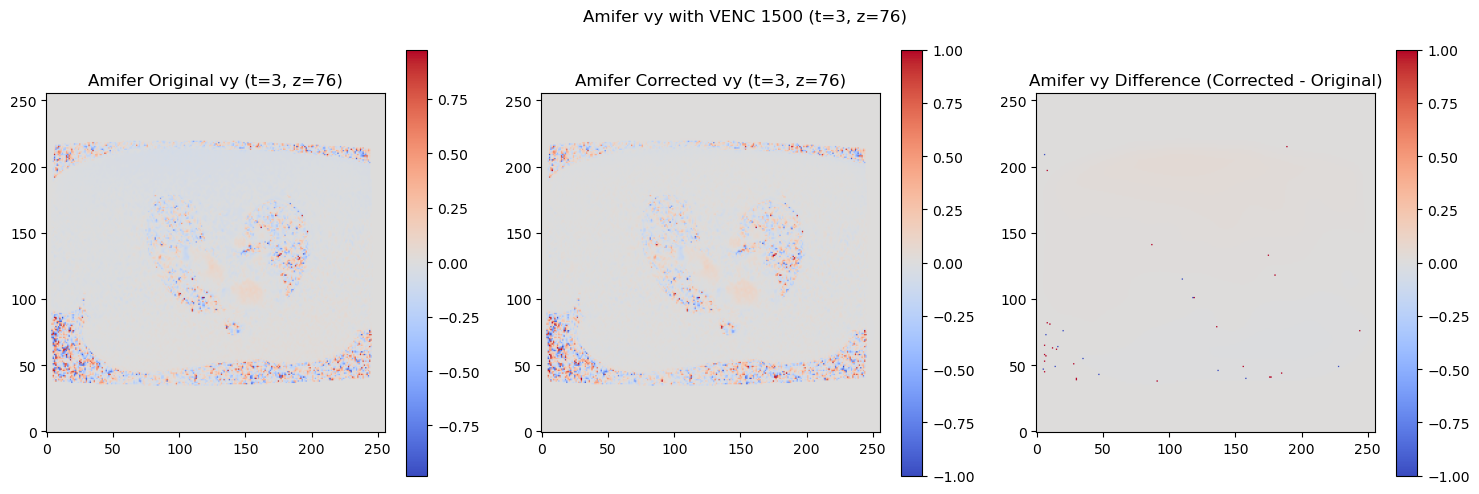

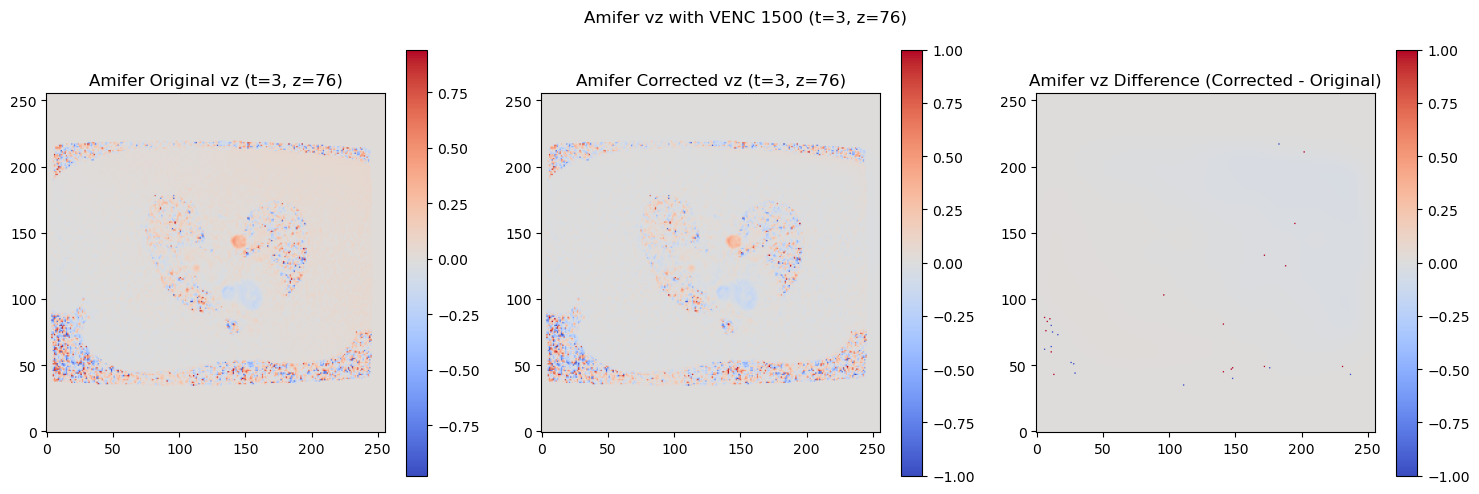

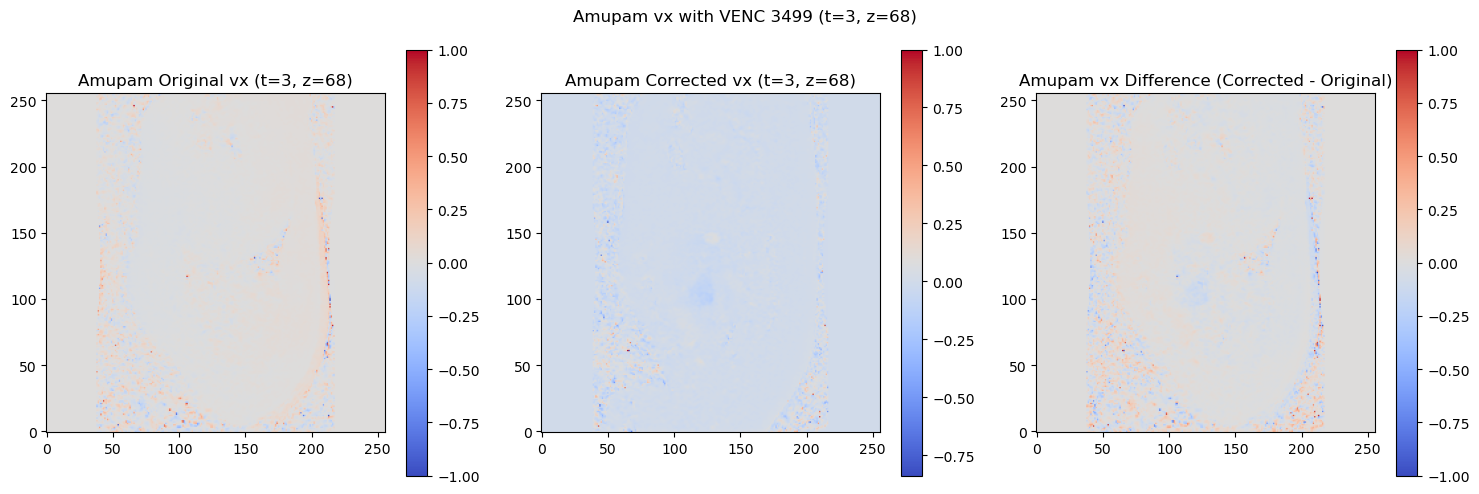

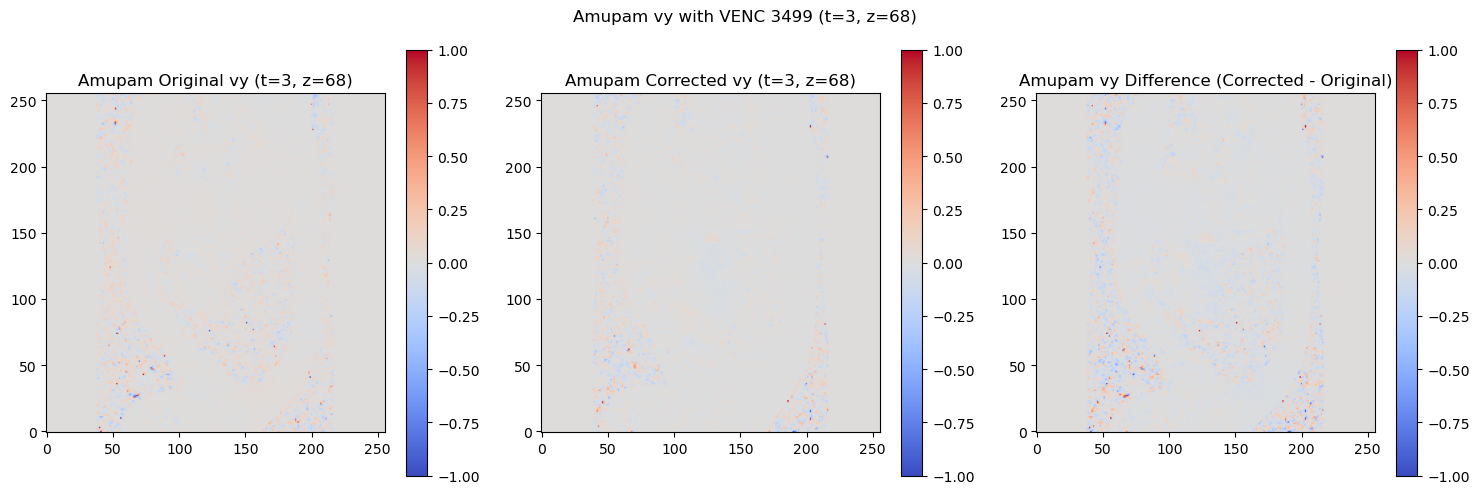

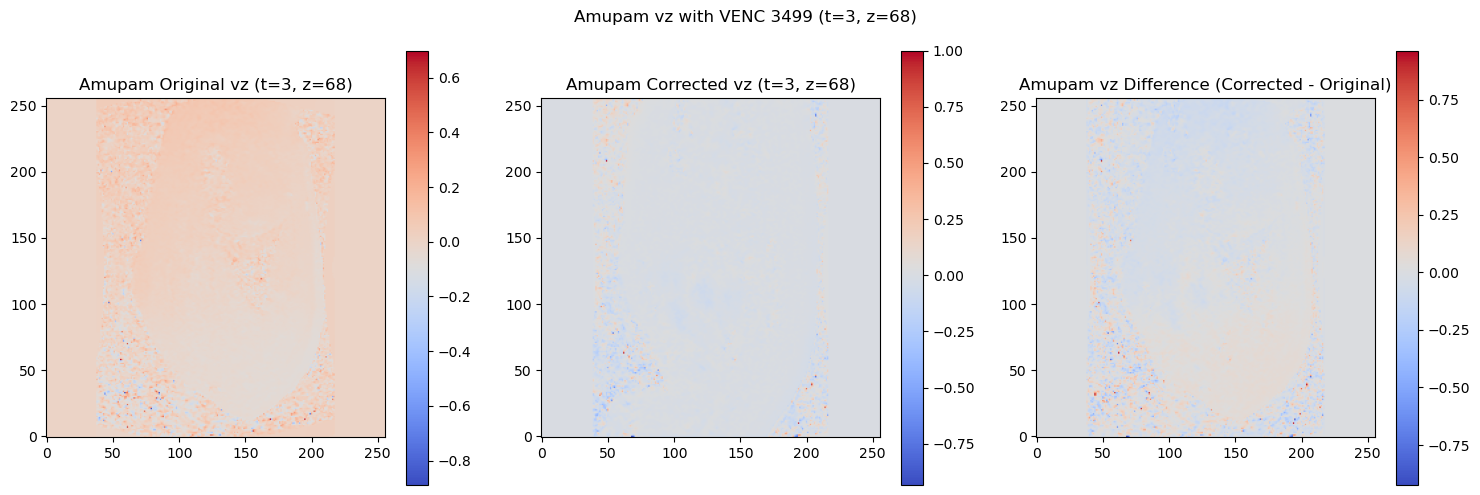

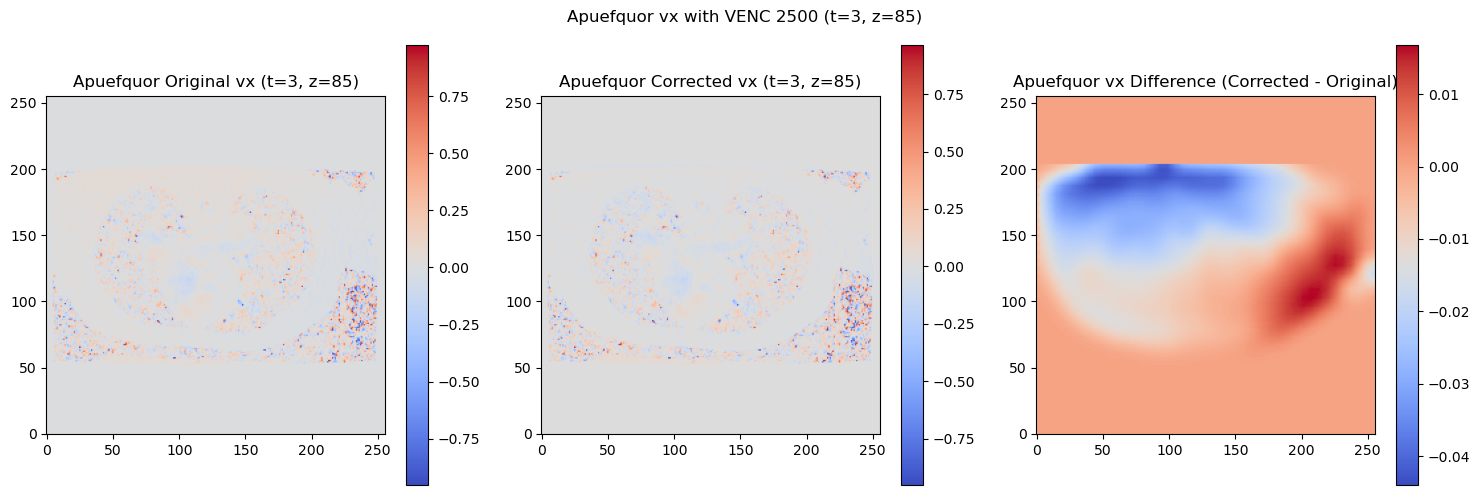

In [ ]:
import os
from tqdm import tqdm

# Add project root to path and import required modules
import sys
sys.path.insert(0, "/home/ayeluru/vascular-superenhancement-4d-flow/src")

from pathlib import Path
import nibabel as nib
from vascular_superenhancement.utils.path_config import load_path_config
from vascular_superenhancement.data_management.patients import Patient

# Load path configuration
path_config = load_path_config("all_patients")
print(f"Repository root: {path_config.repository_root}")
print(f"Working dir: {path_config.working_dir}")

corrected_velocities_dir = path_config.repository_root / "corrected_velocities"
print(f"Corrected velocities directory: {corrected_velocities_dir}")

for patient_vel_file in tqdm(sorted(os.listdir(corrected_velocities_dir))):
    try:
        patient_id = patient_vel_file.split(".")[0]
        # Pick a test patient
        # test_patient_id = "Balboloop"
        patient = Patient(
            path_config=path_config,
            phonetic_id=patient_id,
            skip_database_validation=False,
            overwrite_images=False,  # Set to True to regenerate
        )

        print(f"\nPatient: {patient.identifier}")
        print(f"NIfTI dir: {patient.nifti_dir}")
        print(f"VENC: {get_venc(patient_id)}")

        # # Check if the original velocity NIfTI exists
        # vx_path = patient.nifti_dir / f"4d_flow_vx_{patient.identifier}.nii.gz"
        # print(f"\nReference vx exists: {vx_path.exists()}")
        # if vx_path.exists():
        #     ref = nib.load(vx_path)
        #     print(f"Reference shape: {ref.shape}")
        #     print(f"Reference affine:\n{ref.affine}")

        # Verify the corrected velocities match the original in shape and alignment
        import matplotlib.pyplot as plt
        import numpy as np

        # plot the diffs for each velocity component
        for velocity_component in ["vx", "vy", "vz"]:
            # Load original and corrected vx for comparison
            orig_vx_path = (
                patient.nifti_dir
                / f"4d_flow_{velocity_component}_{patient.identifier}.nii.gz"
            )
            corr_vx_path = (
                patient.nifti_dir
                / f"4d_flow_{velocity_component}_corr_{patient.identifier}.nii.gz"
            )

            orig_vx = nib.load(orig_vx_path)
            corr_vx = nib.load(corr_vx_path)

            orig_data = orig_vx.get_fdata()
            corr_data = corr_vx.get_fdata()
            
            if velocity_component == "vz":
                corr_data = -1 * corr_data
            
            # normalize by venc and clip to -1, 1
            corr_data = np.clip(corr_data / get_venc(patient.identifier), -1, 1)
            orig_data = np.clip(orig_data / get_venc(patient.identifier), -1, 1)

            # print(f"Original shape: {orig_data.shape}")
            # print(f"Corrected shape: {corr_data.shape}")
            # print(f"\nOriginal affine:\n{orig_vx.affine}")
            # print(f"\nCorrected affine:\n{corr_vx.affine}")
            # print(f"\nAffines match: {np.allclose(orig_vx.affine, corr_vx.affine)}")

            # Visualize a slice at a specific timepoint
            t = 3  # timepoint
            z = corr_data.shape[2] // 2  # middle slice

            fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            # Original velocity
            im0 = axes[0].imshow(
                orig_data[:, :, z, t].T, cmap="coolwarm", origin="lower"
            )
            axes[0].set_title(
                f"Original (t={t}, z={z})"
            )
            plt.colorbar(im0, ax=axes[0])

            # Corrected velocity
            im1 = axes[1].imshow(
                corr_data[:, :, z, t].T, cmap="coolwarm", origin="lower"
            )
            axes[1].set_title(
                f"Corrected(t={t}, z={z})"
            )
            plt.colorbar(im1, ax=axes[1])

            # Difference
            diff = np.clip(corr_data[:, :, z, t] - orig_data[:, :, z, t], -1, 1)
            im2 = axes[2].imshow(diff.T, cmap="coolwarm", origin="lower")
            axes[2].set_title(
                "Difference (Corrected - Original)"
            )
            plt.colorbar(im2, ax=axes[2])

            plt.suptitle(f"{patient.identifier} {velocity_component} with VENC {get_venc(patient.identifier)} (t={t}, z={z})")
            plt.tight_layout()
            # save the figure
            plt.savefig(f"/home/ayeluru/vascular-superenhancement-4d-flow/notebooks/sandbox/corr-velocities/{patient.identifier}_{velocity_component}_diff.png")

            # plt.show()

            # Print some statistics about the difference
            print(f"\nDifference statistics {velocity_component}:")
            print(f"  Max abs diff: {np.abs(diff).max():.4f}")
            print(f"  Mean abs diff: {np.abs(diff).mean():.4f}")
            print(
                f"  Non-zero voxels in corrected: {np.count_nonzero(corr_data[:, :, z, t])}"
            )

    except Exception as e:
        print(f"Error processing {patient_vel_file}: {e}")


In [4]:
# Test with a single patient first
corrected_velocities_dir = path_config.repository_root / "corrected_velocities"
print(f"Corrected velocities directory: {corrected_velocities_dir}")

# Pick a test patient
test_patient_id = "Balboloop"
patient = Patient(
    path_config=path_config,
    phonetic_id=test_patient_id,
    skip_database_validation=False,
    overwrite_images=False,  # Set to True to regenerate
)

print(f"\nPatient: {patient.identifier}")
print(f"NIfTI dir: {patient.nifti_dir}")

# Check if the original velocity NIfTI exists
vx_path = patient.nifti_dir / f"4d_flow_vx_{patient.identifier}.nii.gz"
print(f"\nReference vx exists: {vx_path.exists()}")
if vx_path.exists():
    ref = nib.load(vx_path)
    print(f"Reference shape: {ref.shape}")
    print(f"Reference affine:\n{ref.affine}")


Corrected velocities directory: /home/ayeluru/mnt/fourier/repository/vascular-superenhancement-4d-flow/all_patients/corrected_velocities

Patient: Balboloop
NIfTI dir: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Balboloop/nifti

Reference vx exists: True
Reference shape: (256, 256, 140, 20)
Reference affine:
[[ -1.40625083   0.           0.         158.86599731]
 [  0.          -1.40625083   0.         148.21499634]
 [  0.           0.           1.79987395 -89.54589844]
 [  0.           0.           0.           1.        ]]


In [13]:
# Process the test patient
output_paths = process_corrected_velocities(
    patient=patient,
    corrected_velocities_dir=corrected_velocities_dir,
    overwrite=True,  # Set to True to regenerate
)

print("\nOutput paths:")
for name, path in output_paths.items():
    print(f"  {name}: {path}")


[Balboloop] Reference NIfTI shape: (256, 256, 140, 20)
[Balboloop] Corrected numpy shape: (20, 3, 140, 178, 256)
[Balboloop] Corrected: X=256, Y=178, Z=140, T=20
[Balboloop] Reference: X=256, Y=256, Z=140, T=20
[Balboloop] Padding: X=(0,0), Y=(39,39), Z=(0,0)
[Balboloop] vx_corr: padded shape (256, 256, 140, 20)
[Balboloop] Saved vx_corr to /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Balboloop/nifti/4d_flow_vx_corr_Balboloop.nii.gz
[Balboloop] vy_corr: padded shape (256, 256, 140, 20)
[Balboloop] Saved vy_corr to /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Balboloop/nifti/4d_flow_vy_corr_Balboloop.nii.gz
[Balboloop] vz_corr: padded shape (256, 256, 140, 20)
[Balboloop] Saved vz_corr to /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Balboloop/nifti/4d_flow_vz_corr_Balboloop.nii.gz

Output paths:
  vx_corr: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/

Original shape: (256, 256, 140, 20)
Corrected shape: (256, 256, 140, 20)

Original affine:
[[ -1.40625083   0.           0.         158.86599731]
 [  0.          -1.40625083   0.         148.21499634]
 [  0.           0.           1.79987395 -89.54589844]
 [  0.           0.           0.           1.        ]]

Corrected affine:
[[ -1.40625083   0.           0.         158.86599731]
 [  0.          -1.40625083   0.         148.21499634]
 [  0.           0.           1.79987395 -89.54589844]
 [  0.           0.           0.           1.        ]]

Affines match: True


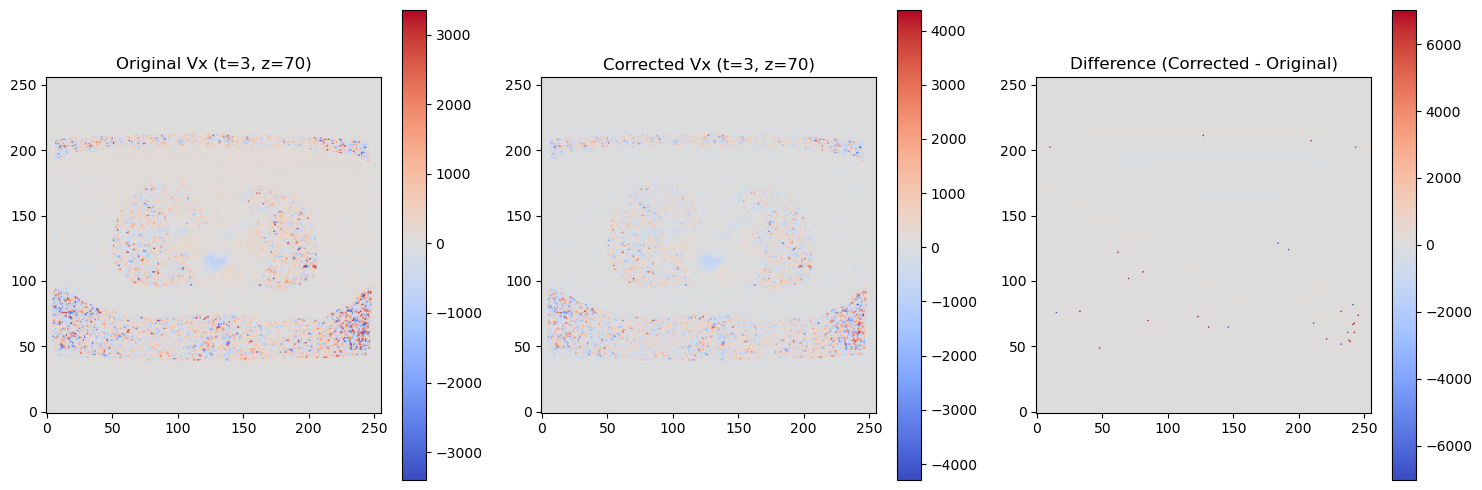


Difference statistics:
  Max abs diff: 7026.0000
  Mean abs diff: 16.9045
  Non-zero voxels in corrected: 42886


In [8]:
# Verify the corrected velocities match the original in shape and alignment
import matplotlib.pyplot as plt
import numpy as np

# Load original and corrected vx for comparison
orig_vx_path = patient.nifti_dir / f"4d_flow_vx_{patient.identifier}.nii.gz"
corr_vx_path = patient.nifti_dir / f"4d_flow_vx_corr_{patient.identifier}.nii.gz"

orig_vx = nib.load(orig_vx_path)
corr_vx = nib.load(corr_vx_path)

orig_data = orig_vx.get_fdata()
corr_data = corr_vx.get_fdata()

print(f"Original shape: {orig_data.shape}")
print(f"Corrected shape: {corr_data.shape}")
print(f"\nOriginal affine:\n{orig_vx.affine}")
print(f"\nCorrected affine:\n{corr_vx.affine}")
print(f"\nAffines match: {np.allclose(orig_vx.affine, corr_vx.affine)}")

# Visualize a slice at a specific timepoint
t = 3  # timepoint
z = corr_data.shape[2] // 2  # middle slice

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original velocity
im0 = axes[0].imshow(orig_data[:, :, z, t].T, cmap='coolwarm', origin='lower')
axes[0].set_title(f"Original Vx (t={t}, z={z})")
plt.colorbar(im0, ax=axes[0])

# Corrected velocity
im1 = axes[1].imshow(corr_data[:, :, z, t].T, cmap='coolwarm', origin='lower')
axes[1].set_title(f"Corrected Vx (t={t}, z={z})")
plt.colorbar(im1, ax=axes[1])

# Difference
# normalize by divding by 1500 and then clipping to -1, 1
diff = corr_data[:, :, z, t] - orig_data[:, :, z, t]
# diff = diff / 3499#np.clip(diff / 1500, -1, 1)
im2 = axes[2].imshow(diff.T, cmap='coolwarm', origin='lower')
axes[2].set_title(f"Difference (Corrected - Original)")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

# Print some statistics about the difference
print(f"\nDifference statistics:")
print(f"  Max abs diff: {np.abs(diff).max():.4f}")
print(f"  Mean abs diff: {np.abs(diff).mean():.4f}")
print(f"  Non-zero voxels in corrected: {np.count_nonzero(corr_data[:, :, z, t])}")


In [ ]:
# Process all patients with corrected velocities
from tqdm import tqdm

# Get list of all corrected velocity files
corrected_files = sorted(corrected_velocities_dir.glob("*.npy"))
print(f"Found {len(corrected_files)} corrected velocity files")

# Track results
successful = []
failed = []

for corr_file in tqdm(corrected_files, desc="Processing patients"):
    patient_id = corr_file.stem  # e.g., "Amifer.npy" -> "Amifer"
    
    try:
        # Create patient object
        patient = Patient(
            path_config=path_config,
            phonetic_id=patient_id,
            skip_database_validation=False,
            overwrite_images=False,
        )
        
        # Check if reference NIfTI exists
        ref_path = patient.nifti_dir / f"4d_flow_vx_{patient.identifier}.nii.gz"
        if not ref_path.exists():
            failed.append((patient_id, "Reference vx NIfTI not found"))
            continue
        
        # Process corrected velocities
        output_paths = process_corrected_velocities(
            patient=patient,
            corrected_velocities_dir=corrected_velocities_dir,
            overwrite=False,  # Don't overwrite existing files
        )
        
        successful.append(patient_id)
        
    except Exception as e:
        failed.append((patient_id, str(e)))

print(f"\n=== Summary ===")
print(f"Successful: {len(successful)}")
print(f"Failed: {len(failed)}")

if failed:
    print("\nFailed patients:")
    for patient_id, error in failed[:10]:  # Show first 10 errors
        print(f"  {patient_id}: {error}")


## Using the Patient Class Methods

The following methods have been added to the `Patient` class and are integrated into the build pipeline:

### Building Corrected Velocities (4D NIfTI files)
```python
patient = Patient(path_config=path_config, phonetic_id="Amifer")
patient.build_corrected_velocities()  # Creates vx_corr, vy_corr, vz_corr NIfTIs
```

### Building Per-Timepoint Files
```python
patient.build_corrected_velocities_per_timepoint()  # Splits into per-frame files (full FOV, no resampling)
patient.build_corrected_speed_per_timepoint()       # Computes speed from corrected velocities
```

### Automatic Integration
These methods are now called automatically when you run:
- `patient.build_images()` - calls `build_corrected_velocities()` if the numpy file exists
- `patient.build_per_timepoint_images()` - calls `build_corrected_velocities_per_timepoint()` and `build_corrected_speed_per_timepoint()` if corrected velocity NIfTIs exist

This means you can run the CLI script as usual and corrected velocities will be processed:
```bash
python -m vascular_superenhancement.commands.build_patients --config all_patients
```


In [14]:
# Alternative: Use the Patient class methods directly
# (Reload the Patient class to get the updated methods)
import importlib
import vascular_superenhancement.data_management.patients as patients_module
importlib.reload(patients_module)
from vascular_superenhancement.data_management.patients import Patient

# Create a patient with overwrite_images=True to regenerate
patient = Patient(
    path_config=path_config,
    phonetic_id="Bibathot",
    overwrite_images=True,
)

# Check paths
print(f"Corrected velocities dir: {patient.corrected_velocities_dir}")
print(f"Corrected velocity numpy path: {patient.corrected_velocity_numpy_path}")
print(f"Numpy file exists: {patient.corrected_velocity_numpy_path.exists()}")

# Build corrected velocities using the class method (creates 4D NIfTIs)
output_paths = patient.build_corrected_velocities()
print("\n4D NIfTI output paths:")
for name, path in output_paths.items():
    print(f"  {name}: {path}")

# Build per-timepoint volumes (full FOV, no resampling)
patient.build_corrected_velocities_per_timepoint()

# Build corrected speed per-timepoint
patient.build_corrected_speed_per_timepoint()

# Show per-timepoint directories
print(f"\nPer-timepoint directories:")
print(f"  vx_corr: {patient.flow_vx_corr_per_timepoint_dir}")
print(f"  vy_corr: {patient.flow_vy_corr_per_timepoint_dir}")
print(f"  vz_corr: {patient.flow_vz_corr_per_timepoint_dir}")
print(f"  speed_corr: {patient.flow_speed_corr_per_timepoint_dir}")


Corrected velocities dir: /home/ayeluru/mnt/fourier/repository/vascular-superenhancement-4d-flow/all_patients/corrected_velocities
Corrected velocity numpy path: /home/ayeluru/mnt/fourier/repository/vascular-superenhancement-4d-flow/all_patients/corrected_velocities/Bibathot.npy
Numpy file exists: True


2026-02-03 22:25:26,771 - INFO - Building corrected velocities for patient Bibathot
2026-02-03 22:25:26,865 - INFO - Reference NIfTI shape: (256, 256, 140, 20)
2026-02-03 22:25:34,712 - INFO - Corrected numpy shape: (20, 3, 140, 178, 256)
2026-02-03 22:25:34,713 - INFO - Padding: X=(0,0), Y=(39,39), Z=(0,0)
2026-02-03 22:25:49,953 - INFO - Saved vx_corr to /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Bibathot/nifti/4d_flow_vx_corr_Bibathot.nii.gz
2026-02-03 22:26:05,353 - INFO - Saved vy_corr to /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Bibathot/nifti/4d_flow_vy_corr_Bibathot.nii.gz
2026-02-03 22:26:20,722 - INFO - Saved vz_corr to /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Bibathot/nifti/4d_flow_vz_corr_Bibathot.nii.gz
2026-02-03 22:26:20,727 - INFO - Building corrected velocity per-timepoint volumes (full FOV) for patient Bibathot



4D NIfTI output paths:
  vx_corr: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Bibathot/nifti/4d_flow_vx_corr_Bibathot.nii.gz
  vy_corr: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Bibathot/nifti/4d_flow_vy_corr_Bibathot.nii.gz
  vz_corr: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Bibathot/nifti/4d_flow_vz_corr_Bibathot.nii.gz


2026-02-03 22:26:21,131 - INFO - Loaded existing DICOM catalog for patient Bibathot
2026-02-03 22:26:21,131 - INFO - Working on vx_corr (full FOV)
2026-02-03 22:26:21,131 - INFO - Building per timepoint volumes for patient Bibathot
2026-02-03 22:26:21,131 - INFO - Loading image from /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Bibathot/nifti/4d_flow_vx_corr_Bibathot.nii.gz
2026-02-03 22:26:23,551 - INFO - Image dimensions: (256, 256, 140, 20)
2026-02-03 22:26:23,931 - INFO - Loaded 20 timepoints
2026-02-03 22:26:34,836 - INFO - Saved 20 timepoints for 4d_flow_vx_corr_Bibathot
2026-02-03 22:26:34,933 - INFO - Working on vy_corr (full FOV)
2026-02-03 22:26:34,933 - INFO - Building per timepoint volumes for patient Bibathot
2026-02-03 22:26:34,933 - INFO - Loading image from /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Bibathot/nifti/4d_flow_vy_corr_Bibathot.nii.gz
2026-02-03 22:26:37,371 - INFO - Image dime


Per-timepoint directories:
  vx_corr: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Bibathot/nifti/4d_flow_vx_corr_Bibathot_per_timepoint
  vy_corr: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Bibathot/nifti/4d_flow_vy_corr_Bibathot_per_timepoint
  vz_corr: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Bibathot/nifti/4d_flow_vz_corr_Bibathot_per_timepoint
  speed_corr: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Bibathot/nifti/4d_flow_speed_corr_Bibathot_per_timepoint


2026-02-03 22:27:22,205 - INFO - Successfully built corrected speed per-timepoint for patient Bibathot
